# Welcome to HiMaLAYAS Quickstart

This notebook provides a minimal working example of **Hierarchical Matrix Layout and Annotation Software (HiMaLAYAS)** for post hoc enrichment-based annotation of hierarchically clustered matrices.

In this quickstart, we apply HiMaLAYAS to a **yeast genetic interaction profile similarity matrix** (Costanzo _et al_., 2016) and annotate clusters with **GO Biological Process** (**GO BP**; Ashburner _et al_., 2000) terms. The matrix focuses on ~1,100 genes with high profile variance.

You will learn how to:
- Load a matrix and annotations
- Cluster and enrich the matrix
- Filter by q-value and summarize clusters
- Plot an annotated figure
- Zoom in on a cluster and re-run enrichment for a focused view

Expected input files in `data`:
- `gi_pcc_sampled.tsv`
- `go_bp_name_to_orfs.json`
- `yeast_essential_orfs.txt`
- `yeast_uncharacterized_orfs.json`


In [1]:
# Imports and setup

import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib.colors import Normalize

import himalayas
from himalayas import Matrix, Annotations, Analysis
from himalayas.plot import Plotter

print(f"HiMaLAYAS version: {himalayas.__version__}")

# Set working directory if running in a notebook environment
if "__file__" not in globals():
    os.chdir(Path().resolve())

# Enable inline plotting for notebooks
%matplotlib inline

HiMaLAYAS version: 0.0.4


---

## Load GO BP Annotations

Load term-to-gene mappings from GO BP.


In [2]:
# Load GO BP annotations and summarize coverage

DATA_DIR = Path("data")
GO_BP_PATH = DATA_DIR / "go_bp_name_to_orfs.json"

with GO_BP_PATH.open("r", encoding="utf-8") as fh:
    go_bp = json.load(fh)


term_sizes = [len(set(orfs)) for orfs in go_bp.values()]
all_orfs = {orf for orfs in go_bp.values() for orf in orfs}

print(f"GO BP terms loaded: {len(term_sizes):,}")
print(f"Min term size: {min(term_sizes)}")
print(f"Max term size: {max(term_sizes)}")
print(f"Unique ORFs across all terms: {len(all_orfs):,}")

GO BP terms loaded: 1,095
Min term size: 5
Max term size: 243
Unique ORFs across all terms: 4,927


---

## Load the Matrix

Load a gene-by-gene similarity matrix (PCC). Rows and columns should have identical labels.


In [3]:
# Load the GI matrix and inspect basic stats

MATRIX_PATH = DATA_DIR / "gi_pcc_sampled.tsv"

DF = pd.read_csv(
    MATRIX_PATH,
    sep="	",
    index_col=0,
)

print(f"Matrix shape: {DF.shape[0]:,} x {DF.shape[1]:,}")
print(f"Row/column labels identical: {DF.index.equals(DF.columns)}")
print(f"Value range: [{DF.min().min():.3f}, {DF.max().max():.3f}]")

DF.head()

Matrix shape: 1,053 x 1,053
Row/column labels identical: True
Value range: [-0.317, 0.845]


,YLR088W,YBR004C,YAR007C,YDL145C,YNL041C,YOR336W,YDR331W,YHR188C,YFL038C,YNL051W,...,YML124C,YLR113W,YJR108W,YJL029C,YPR114W,YGL051W,YGL110C,YMR227C,YGR243W,YKL113C
YLR088W,0.000,0.368,-0.114,0.269,0.108,0.513,0.5195,0.672,0.105,0.177,...,-0.076,0.006,0.051,0.000,-0.044,0.019,0.152,0.090,0.000,-0.111
YBR004C,0.368,0.000,-0.151,0.252,0.254,0.483,0.3445,0.453,0.216,0.236,...,-0.101,0.116,-0.026,0.000,-0.089,-0.076,0.060,0.150,0.000,-0.090
YAR007C,-0.114,-0.151,0.000,-0.177,-0.250,-0.220,-0.1685,-0.165,-0.232,-0.221,...,-0.042,0.076,-0.062,0.000,-0.043,-0.004,-0.041,-0.100,0.000,0.218
YDL145C,0.269,0.252,-0.177,0.002,0.454,0.224,0.3715,0.307,0.422,0.440,...,-0.056,0.024,0.031,0.193,-0.001,-0.015,0.083,0.000,-0.004,-0.088
YNL041C,0.108,0.254,-0.250,0.454,0.002,0.148,0.2290,0.187,0.523,0.788,...,-0.010,0.047,0.038,0.180,0.006,-0.046,0.088,-0.012,-0.033,-0.060


---

## Essential and Uncharacterized Gene Rails

Add gene-level rails to label essential and uncharacterized genes. These tracks are optional and used only for visualization.

---


In [4]:
# Build categorical and continuous rails for label bars

# Set gene order from matrix
genes = DF.index


# Helper functions for categorical rails
def build_binary_gene_map(
    genes,
    positive_set,
    pos_label: str,
    neg_label: str,
):
    """
    Returns {gene -> pos_label/neg_label} based on membership in positive_set.
    """
    return {gene: (pos_label if gene in positive_set else neg_label) for gene in genes}


def load_essential_orfs(path: Path) -> set[str]:
    """
    Loads one ORF per line.
    """
    return {line.strip() for line in path.read_text().splitlines() if line.strip()}


def load_uncharacterized_orfs(path: Path) -> set[str]:
    """
    Loads uncharacterized ORFs from a JSON object keyed by ORF.
    """
    with path.open() as f:
        return set(json.load(f).keys())


def map_essential_genes(genes, essential_orfs: set[str]):
    """
    Maps genes to essential/nonessential labels and return label->color mapping.
    """
    gene_map = build_binary_gene_map(
        genes,
        essential_orfs,
        pos_label="essential",
        neg_label="nonessential",
    )
    colors = {
        "essential": "#d73027",
        "nonessential": "#ffffff",
    }
    return gene_map, colors


def map_uncharacterized_genes(
    genes,
    uncharacterized_orfs: set[str],
    pos_label: str = "uncharacterized",
    neg_label: str = "characterized",
):
    """
    Maps genes to uncharacterized/characterized labels and return label->color mapping.
    """
    gene_map = build_binary_gene_map(
        genes,
        uncharacterized_orfs,
        pos_label=pos_label,
        neg_label=neg_label,
    )
    colors = {
        pos_label: "#1e90ff",
        neg_label: "#ffffff",
    }
    return gene_map, colors


# Categorical rails
essential_path = DATA_DIR / "yeast_essential_orfs.txt"
essential_orfs = load_essential_orfs(essential_path)
gene_essential_map, gene_essential_colors = map_essential_genes(genes, essential_orfs)

print("Total genes:", len(genes))
print(
    "Essential in matrix:",
    sum(v == "essential" for v in gene_essential_map.values()),
)

unchar_path = DATA_DIR / "yeast_uncharacterized_orfs.json"
uncharacterized_orfs = load_uncharacterized_orfs(unchar_path)
gene_characterization_map, gene_characterization_colors = map_uncharacterized_genes(
    genes,
    uncharacterized_orfs,
)

print(
    "Uncharacterized in matrix:",
    sum(v == "uncharacterized" for v in gene_characterization_map.values()),
)

# Continuous rail from the loaded matrix
row_variance_map = DF.var(axis=1).astype(float).to_dict()
row_variance_values = np.fromiter(row_variance_map.values(), dtype=float)
row_variance_min = float(np.nanmin(row_variance_values))
row_variance_max = float(np.nanmax(row_variance_values))

print(f"Row-variance range: [{row_variance_min:.3f}, {row_variance_max:.3f}]")

Total genes: 1053
Essential in matrix: 356
Uncharacterized in matrix: 18
Row-variance range: [0.001, 0.014]


---

## Cluster and Enrich

Build the core objects, run hierarchical clustering, perform hypergeometric enrichment, and compute q-values.


In [5]:
# Run clustering/enrichment and prepare optional cluster labels

LINKAGE_THRESHOLD = 16

matrix = Matrix(DF)
annotations = Annotations(go_bp, matrix)

analysis = (
    Analysis(matrix, annotations)
    .cluster(
        linkage_method="ward",
        linkage_metric="euclidean",
        linkage_threshold=LINKAGE_THRESHOLD,
        min_cluster_size=30,
    )
    .enrich(min_overlap=2)
    .finalize(col_cluster=True, add_qvalues=True)
)

results = analysis.results

# Keep significant terms
results_sig = results.filter("qval <= 0.05")

# Optional post-hoc label table for inspection/export
cluster_labels = results_sig.cluster_labels(label_mode="top_term")

print(f"All enriched rows: {len(results.df):,}")
print(f"Significant rows (q<=0.05): {len(results_sig.df):,}")
print(cluster_labels.head())

/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas/src/himalayas/core/annotations.py:72: RuntimeWarning: Dropped 264/1095 annotations with no overlap to matrix labels
  warn(


All enriched rows: 709
Significant rows (q<=0.05): 331
   cluster                                              label          pval  \
0        1                    GPI anchor biosynthetic process  3.222730e-12   
1        2                         vesicle-mediated transport  1.237408e-26   
2        3                     mRNA splicing, via spliceosome  2.829998e-16   
3        4                            cytoplasmic translation  8.925220e-15   
4        5  mitochondrial respiratory chain complex IV ass...  1.794876e-19   

     n                                               term  
0  148                    GPI anchor biosynthetic process  
1   92                         vesicle-mediated transport  
2  263                     mRNA splicing, via spliceosome  
3  358                            cytoplasmic translation  
4   78  mitochondrial respiratory chain complex IV ass...  


---

## Inspect Results and Clusters

Use these snippets to inspect the results table and cluster membership.


In [6]:
# Results table
display(results.df.head(5), results.df.shape)

# Significant subset
display(results_sig.df.head(5), results_sig.df.shape)

# Cluster sizes and example membership
display(results.clusters.cluster_sizes)
example_cluster = int(results.clusters.unique_clusters[0])
display(sorted(results.clusters.cluster_to_labels[example_cluster])[:10])

# Top terms for the example cluster
display(results_sig.df.query("cluster == @example_cluster").sort_values("pval").head(5))

# Label -> cluster ID lookup
example_label = results.matrix.labels[0]
display(results.clusters.label_to_cluster[example_label])

# Method and key parameters
display(results.method)
display(results.params)

,cluster,term,k,K,n,N,pval,qval
0,6,DNA replication,34,43,52,1053,1.798541e-42,1.275166e-39
1,2,vesicle-mediated transport,33,48,92,1053,1.237408e-26,4.386613e-24
2,2,endoplasmic reticulum to Golgi vesicle-mediate...,24,31,92,1053,3.139344e-21,7.079147e-19
3,6,DNA repair,23,44,52,1053,3.993877e-21,7.079147e-19
4,7,cell division,26,54,62,1053,2.138848e-20,2.707850e-18


(709, 8)

,cluster,term,k,K,n,N,pval,qval
0,6,DNA replication,34,43,52,1053,1.798541e-42,1.275166e-39
1,2,vesicle-mediated transport,33,48,92,1053,1.237408e-26,4.386613e-24
2,2,endoplasmic reticulum to Golgi vesicle-mediate...,24,31,92,1053,3.139344e-21,7.079147e-19
3,6,DNA repair,23,44,52,1053,3.993877e-21,7.079147e-19
4,7,cell division,26,54,62,1053,2.138848e-20,2.707850e-18


(331, 8)

{1: 148, 6: 52, 2: 92, 4: 358, 5: 78, 7: 62, 3: 263}

['YAL023C',
 'YAL056C-A',
 'YAL058W',
 'YBL007C',
 'YBL040C',
 'YBL061C',
 'YBL062W',
 'YBL082C',
 'YBL083C',
 'YBL105C']

,cluster,term,k,K,n,N,pval,qval
25,1,GPI anchor biosynthetic process,18,23,148,1053,3.222730e-12,8.788137e-11
28,1,fungal-type cell wall organization,18,25,148,1053,3.570637e-11,8.729591e-10
30,1,cell wall organization,15,18,148,1053,4.866293e-11,1.112968e-09
47,1,protein N-linked glycosylation,13,17,148,1053,7.445657e-09,1.099786e-07
50,1,dolichol-linked oligosaccharide biosynthetic p...,9,9,148,1053,1.728488e-08,2.402937e-07


1

'hypergeom'

{'linkage_threshold': 16.0}

---

## Plot the Annotated Matrix

Render a figure using the `Plotter`.


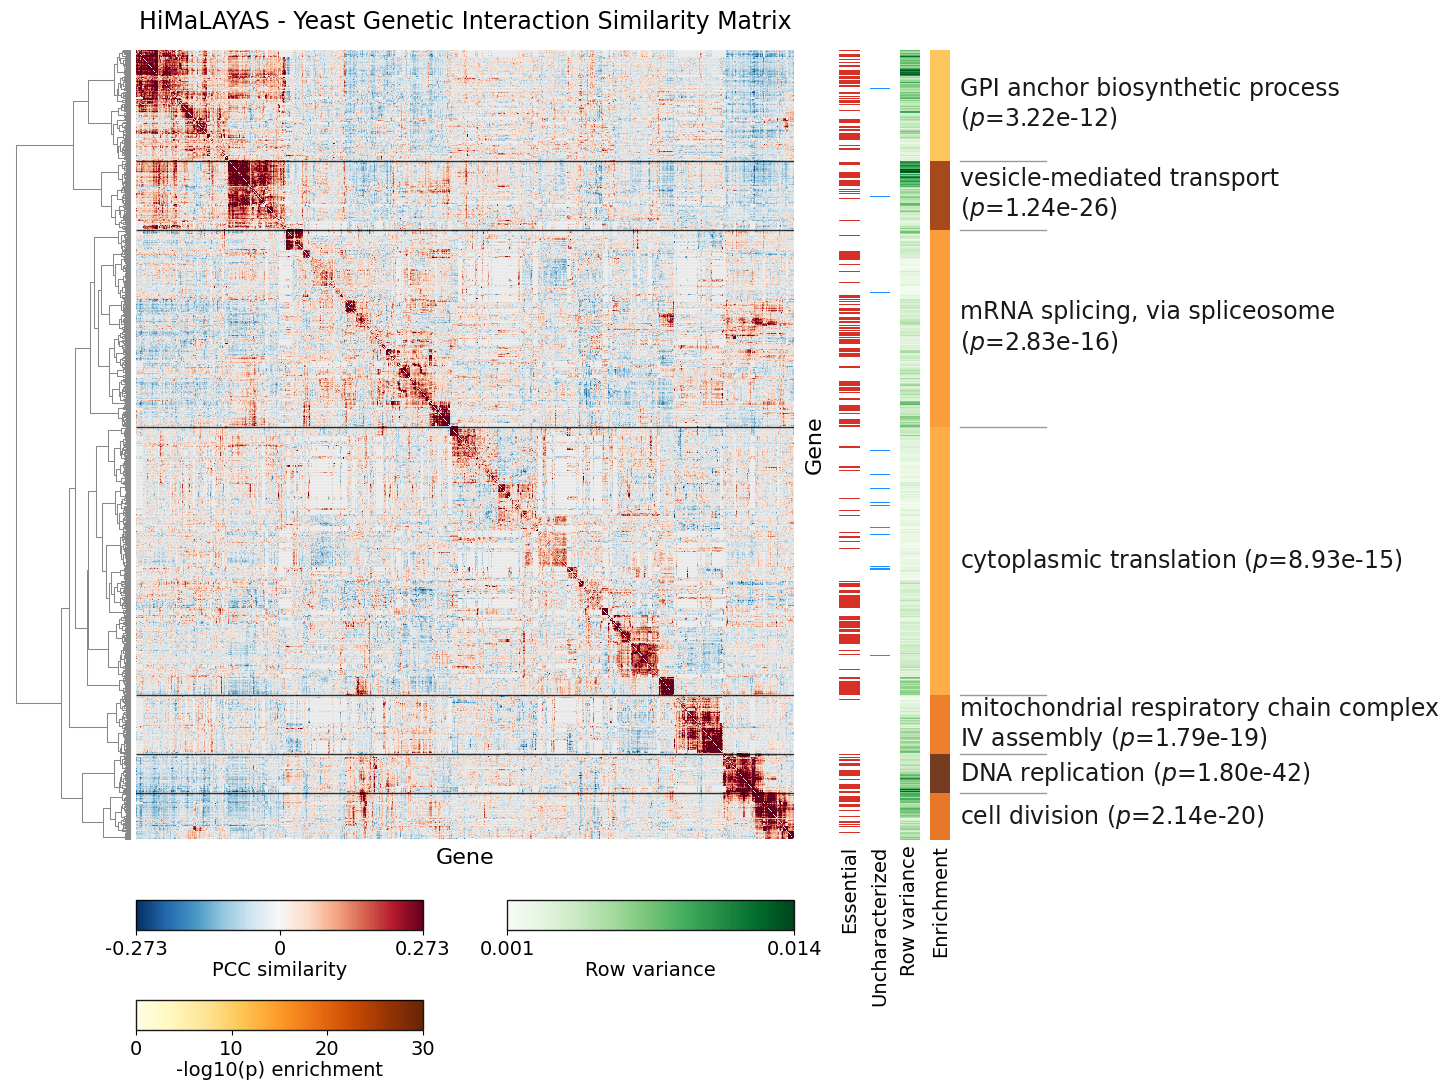

In [7]:
# Configure and render the full plot

LABEL_COLOR = "black"
BACKGROUND_COLOR = "white"

vals = matrix.values
mask = np.isfinite(vals) & (vals != 0)
vlim = float(np.percentile(np.abs(vals[mask]), 99))

plotter = (
    Plotter(results_sig)
    # Build core layout and matrix
    .set_background(color=BACKGROUND_COLOR)
    .plot_title(
        "HiMaLAYAS - Yeast Genetic Interaction Similarity Matrix",
        color=LABEL_COLOR,
        fontsize=17,
    )
    .plot_dendrogram(
        axes=[0.06, 0.16, 0.09, 0.79],
        # data_pad=0.35,
        color="#888888",
        linewidth=0.75,
    )
    .plot_matrix(
        cmap="RdBu_r",
        center=0,
        vmin=-vlim,
        vmax=vlim,
        outer_lw=0,
        figsize=(14, 10),
        subplots_adjust={"left": 0.15, "right": 0.62, "bottom": 0.16, "top": 0.95},
    )
    .plot_matrix_axis_labels(
        xlabel="Gene",
        ylabel="Gene",
        fontsize=16,
        font="DejaVu Sans",
        color=LABEL_COLOR,
        xlabel_pad=6.0,
        ylabel_pad=0.007,
    )
    .plot_cluster_labels(
        max_words=24,
        wrap_text=True,
        wrap_width=40,
        overflow="wrap",
        font="DejaVu Sans",
        fontsize=17,
        color=LABEL_COLOR,
        skip_unlabeled=False,
        label_fields=("label", "p"),
        boundary_color=LABEL_COLOR,
        boundary_lw=1,
        boundary_alpha=0.8,
        dendro_boundary_alpha=0.0,
        label_text_pad=0.02,
        label_sep_xmin=None,
        label_sep_xmax=0.5,
        label_sep_color=LABEL_COLOR,
        label_sep_lw=1,
        label_sep_alpha=0.4,
        label_gutter_color=BACKGROUND_COLOR,
        axes=[0.62, 0.16, 0.36, 0.79],
    )
    # Set label rails and bar-label styles
    .plot_label_bar(
        values=gene_essential_map,
        mode="categorical",
        colors=gene_essential_colors,
        width=0.04,
        left_pad=0.06,
        right_pad=0.0,
        name="essentiality",
        title="Essential",
    )
    .plot_label_bar(
        values=gene_characterization_map,
        mode="categorical",
        colors=gene_characterization_colors,
        width=0.04,
        left_pad=0.02,
        right_pad=0.0,
        name="characterization",
        title="Uncharacterized",
    )
    .plot_label_bar(
        values=row_variance_map,
        mode="continuous",
        cmap="Greens",
        vmin=row_variance_min,
        vmax=row_variance_max,
        width=0.04,
        left_pad=0.02,
        right_pad=0.0,
        name="row_variance",
        title="Row variance",
    )
    .plot_cluster_bar(
        norm=Normalize(0, 30),
        width=0.04,
        left_pad=0.02,
        right_pad=0.00,
        name="sigbar",
        title="Enrichment",
    )
    .plot_bar_labels(
        font="DejaVu Sans",
        fontsize=14,
        color=LABEL_COLOR,
        pad=4,
        rotation=90,
    )
    .set_label_track_order(("essentiality", "characterization", "row_variance", "sigbar"))
    # Set legend style
    .add_colorbar(
        name="matrix",
        cmap="RdBu_r",
        norm=Normalize(-vlim, vlim),
        label="PCC similarity",
        ticks=[-vlim, 0, vlim],
    )
    .add_colorbar(
        name="row_variance",
        cmap="Greens",
        norm=Normalize(row_variance_min, row_variance_max),
        label="Row variance",
        ticks=[row_variance_min, row_variance_max],
    )
    .add_colorbar(
        name="enrichment",
        cmap="YlOrBr",
        norm=Normalize(0, 30),
        label="-log10(p) enrichment",
        ticks=[0, 10, 20, 30],
    )
    .plot_colorbars(
        ncols=2,
        height=0.13,
        gap=0.06,
        hpad=0.06,
        vpad=0.07,
        fontsize=14,
        font="DejaVu Sans",
        color=LABEL_COLOR,
        border_color=LABEL_COLOR,
        border_width=1.0,
        border_alpha=0.9,
        tick_decimals=3,
    )
)

plotter.show()

---

## Condensed Dendrogram

Summarize the cluster hierarchy using a condensed dendrogram that preserves the master ordering.


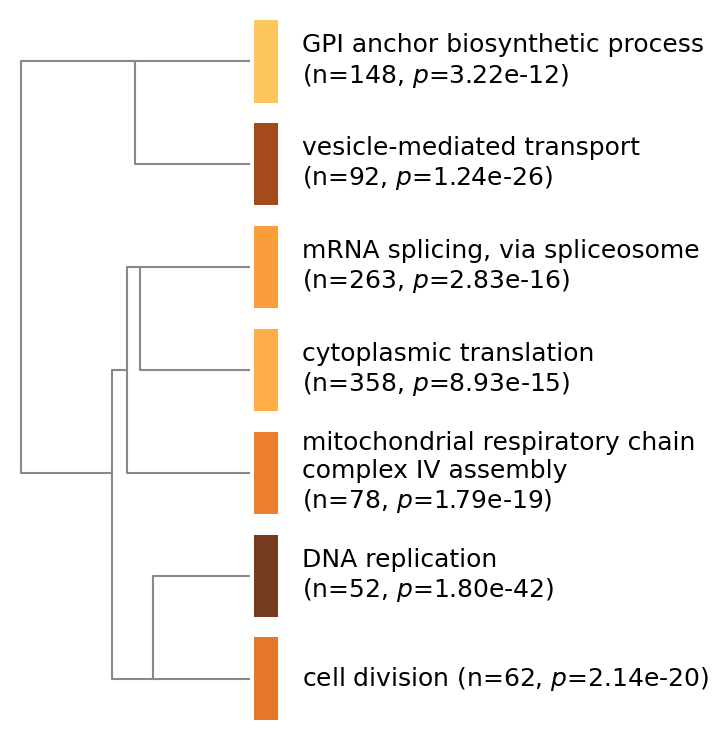

In [8]:
from himalayas.plot import plot_dendrogram_condensed

plot_dendrogram_condensed(
    results_sig,
    figsize=(4, 8),
    sigbar_cmap="YlOrBr",
    sigbar_min_logp=0.0,
    sigbar_max_logp=30.0,
    fontsize=18,
    font="DejaVu Sans",
    max_words=24,
    wrap_text=True,
    wrap_width=34,
    overflow="ellipsis",
    omit_words=(),
    label_fields=("label", "n", "p"),
    label_color=LABEL_COLOR,
    label_left_pad=0.06,
    dendrogram_color="#888888",
    dendrogram_lw=1.5,
    background_color=BACKGROUND_COLOR,
)

---

## Nested Zoom Workflow

Use `Results.subset()` to re-run clustering and enrichment for a single cluster, then plot the zoomed view.


In [9]:
# Define a helper to run zoomed cluster analysis


def run_zoom_analysis(
    *,
    results,
    cluster_id,
    go_bp,
    linkage_threshold,
    min_cluster_size=6,
    min_overlap=2,
    qval_cutoff=0.05,
):
    """
    Runs a localized re-clustering and GO BP enrichment analysis within a selected cluster and
    returns zoomed matrix, results, and filtered results.
    """
    zoom_view = results.subset(cluster=cluster_id)
    zoom_matrix = zoom_view.matrix
    zoom_annotations = Annotations(go_bp, zoom_matrix)
    zoom_analysis = (
        Analysis(zoom_matrix, zoom_annotations)
        .cluster(
            linkage_method="ward",
            linkage_metric="euclidean",
            linkage_threshold=linkage_threshold,
            min_cluster_size=min_cluster_size,
        )
        .enrich(min_overlap=min_overlap, background=results.matrix)
        .finalize(col_cluster=True, add_qvalues=True)
    )
    zoom_results = zoom_analysis.results
    zoom_results_sig = zoom_results.filter(f"qval <= {qval_cutoff}")
    return zoom_matrix, zoom_results, zoom_results_sig


### Plot the Zoomed Matrix

Run the zoom analysis for a cluster, then render a compact figure using the same plotting pipeline.


/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas/src/himalayas/core/annotations.py:72: RuntimeWarning: Dropped 658/1095 annotations with no overlap to matrix labels
  warn(


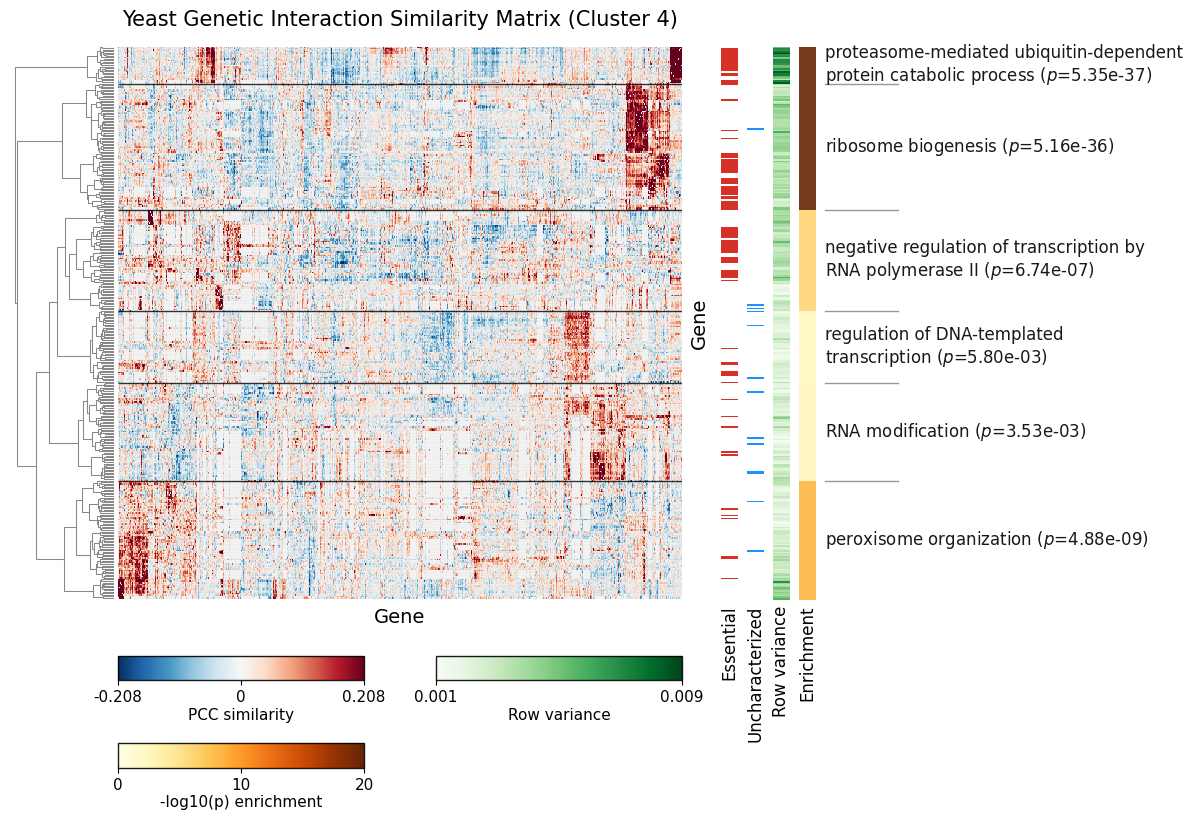

In [12]:
# Run zoomed analysis and render the zoomed plot

CLUSTER_ID = 4
ZOOM_LINKAGE_THRESHOLD = 8

zoom_matrix, zoom_results, zoom_results_sig = run_zoom_analysis(
    results=results,
    cluster_id=CLUSTER_ID,
    go_bp=go_bp,
    linkage_threshold=ZOOM_LINKAGE_THRESHOLD,
)

vals = zoom_matrix.values
mask = np.isfinite(vals) & (vals != 0)
vlim = float(np.percentile(np.abs(vals[mask]), 99))

zoom_row_variance_map = zoom_matrix.df.var(axis=1).astype(float).to_dict()
zoom_row_variance_values = np.fromiter(zoom_row_variance_map.values(), dtype=float)
zoom_row_variance_min = float(np.nanmin(zoom_row_variance_values))
zoom_row_variance_max = float(np.nanmax(zoom_row_variance_values))

plotter = (
    Plotter(zoom_results_sig)
    .set_background(color=BACKGROUND_COLOR)
    .plot_title(
        f"Yeast Genetic Interaction Similarity Matrix (Cluster {CLUSTER_ID})",
        color=LABEL_COLOR,
        fontsize=15,
    )
    .plot_dendrogram(
        axes=[0.06, 0.16, 0.09, 0.79],
        data_pad=1,
        color="#888888",
        linewidth=0.75,
    )
    .plot_matrix(
        cmap="RdBu_r",
        center=0,
        vmin=-vlim,
        vmax=vlim,
        outer_lw=0,
        figsize=(12, 7),
        subplots_adjust={"left": 0.15, "right": 0.62, "bottom": 0.16, "top": 0.95},
    )
    .plot_matrix_axis_labels(
        xlabel="Gene",
        ylabel="Gene",
        fontsize=14,
        font="DejaVu Sans",
        color=LABEL_COLOR,
        xlabel_pad=6.0,
        ylabel_pad=0.007,
    )
    .plot_cluster_labels(
        max_words=24,
        wrap_text=True,
        wrap_width=40,
        overflow="wrap",
        font="DejaVu Sans",
        fontsize=12,
        color=LABEL_COLOR,
        skip_unlabeled=False,
        label_fields=("label", "p"),
        boundary_color=LABEL_COLOR,
        boundary_lw=1,
        boundary_alpha=0.8,
        dendro_boundary_alpha=0.0,
        label_text_pad=0.02,
        label_sep_xmin=None,
        label_sep_xmax=0.5,
        label_sep_color=LABEL_COLOR,
        label_sep_lw=1,
        label_sep_alpha=0.4,
        label_gutter_color=BACKGROUND_COLOR,
        axes=[0.62, 0.16, 0.36, 0.79],
    )
    .plot_label_bar(
        values=gene_essential_map,
        mode="categorical",
        colors=gene_essential_colors,
        left_pad=0.06,
        width=0.04,
        right_pad=0.0,
        name="essentiality",
        title="Essential",
    )
    .plot_label_bar(
        values=gene_characterization_map,
        mode="categorical",
        colors=gene_characterization_colors,
        width=0.04,
        left_pad=0.02,
        right_pad=0.0,
        name="characterization",
        title="Uncharacterized",
    )
    .plot_label_bar(
        values=zoom_row_variance_map,
        mode="continuous",
        cmap="Greens",
        vmin=zoom_row_variance_min,
        vmax=zoom_row_variance_max,
        width=0.04,
        left_pad=0.02,
        right_pad=0.0,
        name="row_variance",
        title="Row variance",
    )
    .plot_cluster_bar(
        norm=Normalize(0, 20),
        name="sigbar",
        title="Enrichment",
        width=0.04,
        left_pad=0.02,
        right_pad=0.0,
    )
    .plot_bar_labels(
        font="DejaVu Sans",
        fontsize=12,
        color=LABEL_COLOR,
        pad=4,
        rotation=90,
    )
    .set_label_track_order(("essentiality", "characterization", "row_variance", "sigbar"))
    .add_colorbar(
        name="matrix",
        cmap="RdBu_r",
        norm=Normalize(-vlim, vlim),
        label="PCC similarity",
        ticks=[-vlim, 0, vlim],
    )
    .add_colorbar(
        name="row_variance",
        cmap="Greens",
        norm=Normalize(zoom_row_variance_min, zoom_row_variance_max),
        label="Row variance",
        ticks=[zoom_row_variance_min, zoom_row_variance_max],
    )
    .add_colorbar(
        name="enrichment",
        cmap="YlOrBr",
        norm=Normalize(0, 20),
        label="-log10(p) enrichment",
        ticks=[0, 10, 20],
    )
    .plot_colorbars(
        ncols=2,
        height=0.16,
        gap=0.08,
        hpad=0.06,
        vpad=0.09,
        fontsize=11,
        font="DejaVu Sans",
        color=LABEL_COLOR,
        border_color=LABEL_COLOR,
        border_width=1.0,
        border_alpha=0.9,
        tick_decimals=3,
    )
)

plotter.show()